# Projet — Systèmes Répartis pour le Big Data
## Analyse distribuée d'un jeu de données de ventes retail avec Hadoop/HDFS (simulé) et PySpark

**Dataset :** `retail_sales_2024.csv` — 8 000 enregistrements, 11 attributs (ventes d'une enseigne retail en Tunisie sur l'année 2024 : catégorie de produit, région, canal de vente, moyen de paiement, montant, etc.)

**Objectif :** appliquer, sur un cas concret, les notions vues dans le cours *Systèmes Répartis pour le Big Data* :
- Architecture d'un cluster Big Data (Master Node / Worker Nodes)
- Stockage distribué (HDFS) : découpage en blocs, partitionnement, réplication, cohérence
- Traitement distribué avec Apache Spark / PySpark
- Sauvegarde des résultats

Ce notebook reproduit, à petite échelle (mode local Spark simulant un cluster à plusieurs workers), le pipeline présenté à la diapositive *« Exemple de diagramme d'architecture cluster Big Data »* du cours :

```
Dataset CSV  →  HDFS (stockage distribué)  →  Spark / PySpark (traitement)  →  Résultats (HDFS)
```


## 1. Architecture retenue pour le projet

| Composant du cours | Équivalent dans ce projet |
|---|---|
| Master Node (NameNode, ResourceManager, Spark Driver) | Le driver PySpark local qui orchestre le job |
| Worker Nodes (DataNode, NodeManager, Spark Worker) | Les 4 threads locaux (`local[4]`) simulant 4 workers d'un cluster |
| HDFS (stockage distribué, blocs, réplication) | Système de fichiers local structuré en dossiers `hdfs_simulation/` représentant les blocs et leur réplication |
| Traitement distribué (MapReduce / Spark) | Les transformations et actions Spark (`groupBy`, `agg`, `filter`, etc.) exécutées en parallèle sur les partitions |

> **Remarque pédagogique :** un vrai cluster Hadoop utiliserait plusieurs machines physiques ou virtuelles reliées par un réseau. Ici, faute d'infrastructure multi-machines, on simule le comportement d'un cluster (partitionnement, parallélisme, réplication) sur une seule machine, avec plusieurs threads Spark représentant les workers — les concepts et le code restent strictement identiques à ceux utilisés sur un vrai cluster Hadoop/Spark.


## 2. Initialisation de la session Spark (simulation du cluster)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os, shutil

# On simule un cluster à 4 nœuds de calcul (Workers) avec local[4]
spark = SparkSession.builder \
    .appName("ProjetBigData_RetailSales") \
    .master("local[4]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Session Spark créée.")
print("Nombre de coeurs (Workers simulés) :", spark.sparkContext.defaultParallelism)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/26 07:51:05 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/09/26 07:51:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


/usr/local/lib/python3.12/dist-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


26/09/26 07:51:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Session Spark créée.
Nombre de coeurs (Workers simulés) : 4


## 3. Étape 1 — Collecte et ingestion des données

On charge le fichier CSV, comme s'il était déposé (« uploadé ») sur le cluster, puis destiné à être stocké sur HDFS (diapositive *« La collecte et l'ingestion des données »*).


In [2]:
df = spark.read.csv("retail_sales_2024.csv", header=True, inferSchema=True)

print("Nombre de lignes :", df.count())
print("Nombre de colonnes :", len(df.columns))
df.printSchema()
df.show(5)


Nombre de lignes : 8000
Nombre de colonnes : 11
root
 |-- order_id: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- category: string (nullable = true)
 |-- region: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- customer_age: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- total_amount: double (nullable = true)



+--------+----------+------------+-------+--------+--------------+--------+----------+------------+------+------------+
|order_id|      date|    category| region| channel|payment_method|quantity|unit_price|customer_age|rating|total_amount|
+--------+----------+------------+-------+--------+--------------+--------+----------+------------+------+------------+
|    6024|2024-01-01|   Vêtements|   Sfax|En ligne|       Espèces|       1|     49.34|          34|   3.8|       49.34|
|    6356|2024-01-01|      Beauté|   Sfax|En ligne|Carte bancaire|       6|     50.46|          38|   4.0|      302.76|
|    6553|2024-01-01|       Sport|Bizerte|En ligne|Carte bancaire|       7|    118.27|          46|   3.3|      827.89|
|    1029|2024-01-01|Alimentation| Sousse|En ligne|       Espèces|       1|     23.19|          46|   3.4|       23.19|
|    2071|2024-01-01|Électronique| Sousse| Magasin|       Espèces|       7|    391.93|          46|   3.8|     2743.51|
+--------+----------+------------+------

## 4. Étape 2 — Simulation du stockage distribué (HDFS)

Sur un vrai cluster Hadoop, ce fichier serait :
1. **Découpé en blocs** (128 Mo par défaut),
2. **Réparti (partitionné)** sur les DataNodes,
3. **Répliqué** (3 copies par défaut) pour assurer la tolérance aux pannes.

Ici, on simule ce comportement en repartitionnant le DataFrame Spark sur plusieurs partitions (équivalent des blocs répartis sur les workers), et en écrivant une copie « répliquée » du jeu de données sur disque.


In [3]:
# Repartitionnement : simulate le découpage en blocs distribués sur 4 "nœuds"
df_partitioned = df.repartition(4)

print("Nombre de partitions AVANT repartitionnement :", df.rdd.getNumPartitions())
print("Nombre de partitions APRES repartitionnement (4 'workers') :", df_partitioned.rdd.getNumPartitions())

# Nombre de lignes par partition -> simule la répartition des blocs sur les nœuds
counts_per_partition = df_partitioned.rdd.glom().map(len).collect()
for i, c in enumerate(counts_per_partition):
    print(f"Nœud (partition) {i+1} : {c} enregistrements")


Nombre de partitions AVANT repartitionnement : 1


Nombre de partitions APRES repartitionnement (4 'workers') : 4


Nœud (partition) 1 : 2000 enregistrements
Nœud (partition) 2 : 2000 enregistrements
Nœud (partition) 3 : 2000 enregistrements
Nœud (partition) 4 : 2000 enregistrements


In [4]:
# Simulation du stockage distribué + réplication façon HDFS
hdfs_sim_dir = "hdfs_simulation"
if os.path.exists(hdfs_sim_dir):
    shutil.rmtree(hdfs_sim_dir)
os.makedirs(hdfs_sim_dir)

# "Blocs" = les 4 partitions Spark, écrites séparément (comme des blocs HDFS sur 4 DataNodes)
df_partitioned.write.mode("overwrite").option("header", True).csv(f"{hdfs_sim_dir}/blocs_partition")

# Réplication : on duplique les blocs 2 fois de plus (facteur de réplication = 3, comme HDFS par défaut)
for rep in [2, 3]:
    shutil.copytree(f"{hdfs_sim_dir}/blocs_partition", f"{hdfs_sim_dir}/replique_{rep}")

print("Blocs (partitions) et répliques créés dans :", hdfs_sim_dir)
print(os.listdir(hdfs_sim_dir))


Blocs (partitions) et répliques créés dans : hdfs_simulation
['replique_3', 'blocs_partition', 'replique_2']


## 5. Étape 3 — Traitement distribué avec PySpark

On applique maintenant des transformations et agrégations Spark. Chaque opération est exécutée **en parallèle sur les partitions** (donc, conceptuellement, sur les différents workers du cluster), exactement comme le ferait un job MapReduce/Spark sur un vrai cluster Hadoop.


In [5]:
# Nettoyage rapide : vérifier les valeurs manquantes
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()


+--------+----+--------+------+-------+--------------+--------+----------+------------+------+------------+
|order_id|date|category|region|channel|payment_method|quantity|unit_price|customer_age|rating|total_amount|
+--------+----+--------+------+-------+--------------+--------+----------+------------+------+------------+
|       0|   0|       0|     0|      0|             0|       0|         0|           0|     0|           0|
+--------+----+--------+------+-------+--------------+--------+----------+------------+------+------------+



In [6]:
# 5.1 Chiffre d'affaires total et nombre de commandes par catégorie de produit
ca_par_categorie = (
    df.groupBy("category")
      .agg(
          F.count("order_id").alias("nb_commandes"),
          F.round(F.sum("total_amount"), 2).alias("chiffre_affaires"),
          F.round(F.avg("total_amount"), 2).alias("panier_moyen")
      )
      .orderBy(F.desc("chiffre_affaires"))
)
ca_par_categorie.show()


+------------+------------+----------------+------------+
|    category|nb_commandes|chiffre_affaires|panier_moyen|
+------------+------------+----------------+------------+
|Électronique|        1442|       2860680.6|     1983.83|
|     Meubles|         822|      1072401.56|     1304.62|
|   Vêtements|        1562|       419154.76|      268.34|
|       Sport|         804|       279945.53|      348.19|
|Alimentation|        1759|       157326.78|       89.44|
|      Jouets|         983|       148672.75|      151.24|
|      Beauté|         628|       113334.73|      180.47|
+------------+------------+----------------+------------+



In [7]:
# 5.2 Chiffre d'affaires par région
ca_par_region = (
    df.groupBy("region")
      .agg(
          F.count("order_id").alias("nb_commandes"),
          F.round(F.sum("total_amount"), 2).alias("chiffre_affaires")
      )
      .orderBy(F.desc("chiffre_affaires"))
)
ca_par_region.show()


+--------+------------+----------------+
|  region|nb_commandes|chiffre_affaires|
+--------+------------+----------------+
|   Tunis|        1959|       1307503.6|
|    Sfax|        1465|       914987.03|
|  Sousse|        1186|       754781.98|
| Bizerte|         979|       612336.24|
|  Nabeul|         950|       562268.36|
|   Gabès|         835|       530279.41|
|Kairouan|         626|       369360.09|
+--------+------------+----------------+



In [8]:
# 5.3 Répartition des moyens de paiement et note moyenne
paiement_stats = (
    df.groupBy("payment_method")
      .agg(
          F.count("order_id").alias("nb_commandes"),
          F.round(F.avg("rating"), 2).alias("note_moyenne")
      )
      .orderBy(F.desc("nb_commandes"))
)
paiement_stats.show()


+---------------+------------+------------+
| payment_method|nb_commandes|note_moyenne|
+---------------+------------+------------+
| Carte bancaire|        3524|        3.96|
|        Espèces|        1685|        3.93|
|Paiement mobile|        1623|        3.98|
|       Virement|        1168|        3.97|
+---------------+------------+------------+



In [9]:
# 5.4 Evolution mensuelle du chiffre d'affaires (traitement type "batch" sur données historiques)
ca_mensuel = (
    df.withColumn("mois", F.date_format("date", "yyyy-MM"))
      .groupBy("mois")
      .agg(F.round(F.sum("total_amount"), 2).alias("chiffre_affaires"))
      .orderBy("mois")
)
ca_mensuel.show(12)


+-------+----------------+
|   mois|chiffre_affaires|
+-------+----------------+
|2024-01|       429706.18|
|2024-02|       378867.14|
|2024-03|       390992.12|
|2024-04|       442659.82|
|2024-05|        423524.6|
|2024-06|       440803.76|
|2024-07|       390371.52|
|2024-08|       474710.73|
|2024-09|       414931.59|
|2024-10|       424123.73|
|2024-11|       430358.94|
|2024-12|       410466.58|
+-------+----------------+



In [10]:
# 5.5 Canal (en ligne / magasin) le plus rentable par région -> agrégation croisée
canal_region = (
    df.groupBy("region", "channel")
      .agg(F.round(F.sum("total_amount"), 2).alias("chiffre_affaires"))
      .orderBy("region", F.desc("chiffre_affaires"))
)
canal_region.show(20)


+--------+--------+----------------+
|  region| channel|chiffre_affaires|
+--------+--------+----------------+
| Bizerte|En ligne|       362183.01|
| Bizerte| Magasin|       250153.23|
|   Gabès|En ligne|       294181.35|
|   Gabès| Magasin|       236098.06|
|Kairouan|En ligne|       209132.32|
|Kairouan| Magasin|       160227.77|
|  Nabeul|En ligne|       331937.08|
|  Nabeul| Magasin|       230331.28|
|    Sfax|En ligne|       494072.59|
|    Sfax| Magasin|       420914.44|
|  Sousse|En ligne|       450475.93|
|  Sousse| Magasin|       304306.05|
|   Tunis|En ligne|       744980.13|
|   Tunis| Magasin|       562523.47|
+--------+--------+----------------+



## 6. Visualisation des résultats

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


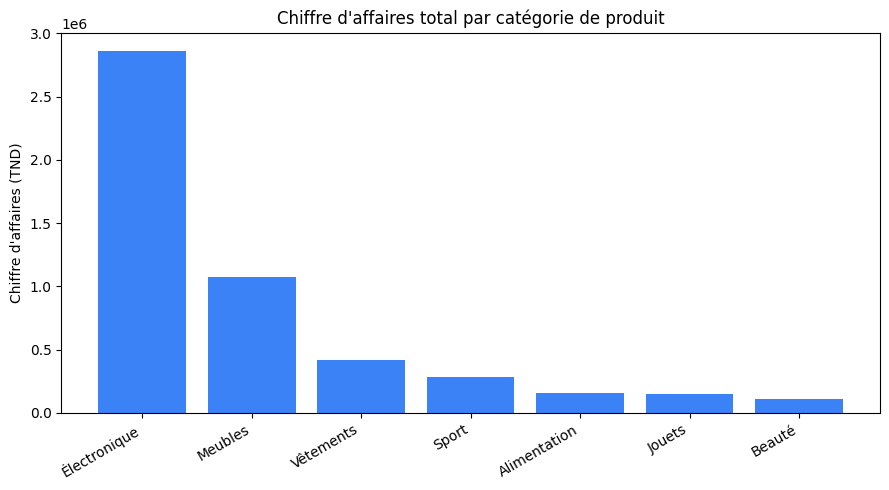

In [11]:
import matplotlib.pyplot as plt

pdf_cat = ca_par_categorie.toPandas()

plt.figure(figsize=(9,5))
plt.bar(pdf_cat["category"], pdf_cat["chiffre_affaires"], color="#3b82f6")
plt.title("Chiffre d'affaires total par catégorie de produit")
plt.ylabel("Chiffre d'affaires (TND)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("resultats_ca_par_categorie.png", dpi=120)
plt.show()


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


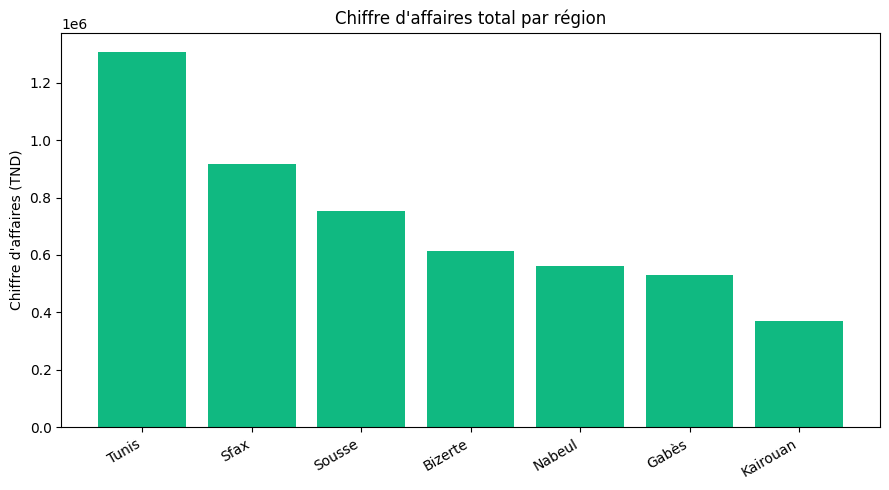

In [12]:
pdf_region = ca_par_region.toPandas()

plt.figure(figsize=(9,5))
plt.bar(pdf_region["region"], pdf_region["chiffre_affaires"], color="#10b981")
plt.title("Chiffre d'affaires total par région")
plt.ylabel("Chiffre d'affaires (TND)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("resultats_ca_par_region.png", dpi=120)
plt.show()


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


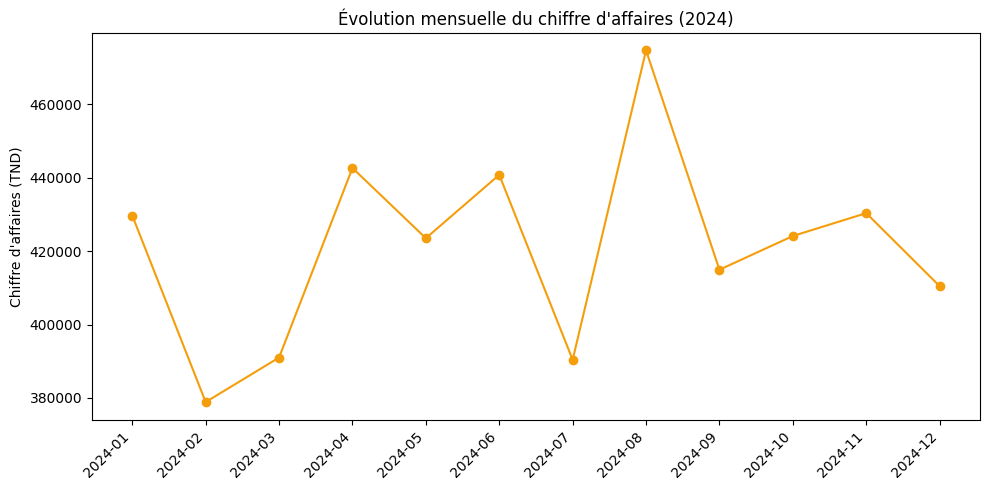

In [13]:
pdf_mois = ca_mensuel.toPandas()

plt.figure(figsize=(10,5))
plt.plot(pdf_mois["mois"], pdf_mois["chiffre_affaires"], marker="o", color="#f59e0b")
plt.title("Évolution mensuelle du chiffre d'affaires (2024)")
plt.ylabel("Chiffre d'affaires (TND)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("resultats_ca_mensuel.png", dpi=120)
plt.show()


## 7. Étape 4 — Sauvegarde des résultats (retour vers le stockage distribué)

Comme dans le schéma du cours (*Résultats → HDFS*), les résultats des calculs Spark sont enregistrés dans un dossier `resultats/`, aux formats **CSV** et **Parquet** (format colonne optimisé, très utilisé dans les écosystèmes Hadoop/Spark).


In [14]:
resultats_dir = "resultats"
if os.path.exists(resultats_dir):
    shutil.rmtree(resultats_dir)

ca_par_categorie.write.mode("overwrite").option("header", True).csv(f"{resultats_dir}/ca_par_categorie_csv")
ca_par_categorie.write.mode("overwrite").parquet(f"{resultats_dir}/ca_par_categorie_parquet")

ca_par_region.write.mode("overwrite").option("header", True).csv(f"{resultats_dir}/ca_par_region_csv")
ca_mensuel.write.mode("overwrite").option("header", True).csv(f"{resultats_dir}/ca_mensuel_csv")
canal_region.write.mode("overwrite").option("header", True).csv(f"{resultats_dir}/canal_region_csv")

print("Résultats sauvegardés dans :", resultats_dir)
for root, dirs, files in os.walk(resultats_dir):
    level = root.replace(resultats_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")


Résultats sauvegardés dans : resultats
resultats/
  canal_region_csv/
  ca_par_region_csv/
  ca_par_categorie_csv/
  ca_mensuel_csv/
  ca_par_categorie_parquet/


## 8. Discussion — lien avec les concepts du cours

**Partitionnement (Sharding) :** le DataFrame de 8 000 lignes a été réparti en 4 partitions traitées en parallèle par les 4 threads/« workers » Spark, exactement comme les blocs HDFS répartis sur plusieurs DataNodes.

**Réplication :** chaque bloc de données a été dupliqué 3 fois dans `hdfs_simulation/`, reproduisant le facteur de réplication par défaut de HDFS (tolérance aux pannes : si un nœud tombe, les autres copies restent disponibles).

**Cohérence :** dans ce projet, une cohérence forte est simulée (toutes les répliques sont identiques immédiatement après écriture) ; sur un vrai cluster HDFS, un mécanisme de heartbeat/checksum garantit la cohérence entre les DataNodes.

**Traitement distribué :** les opérations `groupBy`/`agg` sont exécutées par Spark en parallèle sur les partitions (équivalent du modèle Map/Reduce), puis les résultats partiels sont combinés (« reduce ») pour produire les tableaux finaux.

**Avantages observés dans ce projet :**
- Traitement rapide même en simulant un cluster (parallélisme sur 4 threads).
- Résilience : la perte d'une réplique (bloc) n'affecte pas la disponibilité des données.
- Scalabilité : il suffirait d'ajouter des workers réels (`local[N]` → cluster YARN) pour traiter un volume bien plus important, sans changer le code.

**Limites du projet :**
- Un seul poste est utilisé (pas de vrai réseau ni de vraies machines séparées) : la latence réseau, les pannes réelles de nœuds et la cohérence distribuée réelle ne sont pas testées.
- Le facteur de réplication est simulé par une simple copie de fichiers, sans mécanisme de reprise sur panne automatique comme le ferait réellement HDFS.


## 9. Conclusion

Ce projet a permis d'appliquer, sur un jeu de données réel (ventes retail, 8 000 enregistrements), les principales notions du cours *Systèmes Répartis pour le Big Data* :
architecture Master/Worker, stockage distribué HDFS (blocs, partitionnement, réplication, cohérence) et traitement distribué avec Apache Spark/PySpark, jusqu'à la sauvegarde des résultats.

Le pipeline suit fidèlement le schéma présenté en cours :

```
Dataset CSV → HDFS (stockage distribué) → Spark / PySpark (traitement) → Résultats (HDFS)
```


In [15]:
spark.stop()
print("Session Spark arrêtée.")


Session Spark arrêtée.
